umbralizacion binaria y binaria inversa

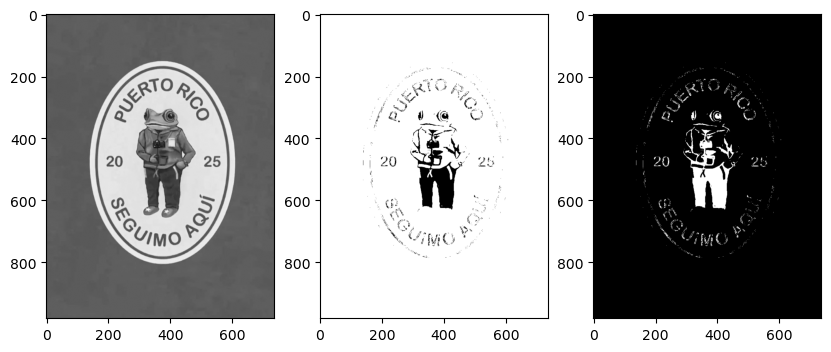

In [4]:
import cv2 
import matplotlib.pyplot as plt
imagen = cv2.imread('concho.jpg',0)#lee la escala de grises
#umbralizacion binaria 
_,umbral_binario=cv2.threshold(imagen,127,255,cv2.THRESH_BINARY)
#umbralizacion binaria inversa
_,umbral_binario_inverso=cv2.threshold(imagen,127,255,cv2.THRESH_BINARY_INV)

plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.imshow(imagen,cmap='gray')

plt.subplot(1,3,2)
plt.imshow(umbral_binario,cmap='gray')

plt.subplot(1,3,3)
plt.imshow(umbral_binario_inverso,cmap='gray')
plt.show()

filtro bayer

Creando patrón Bayer...
Reconstruyendo imagen...


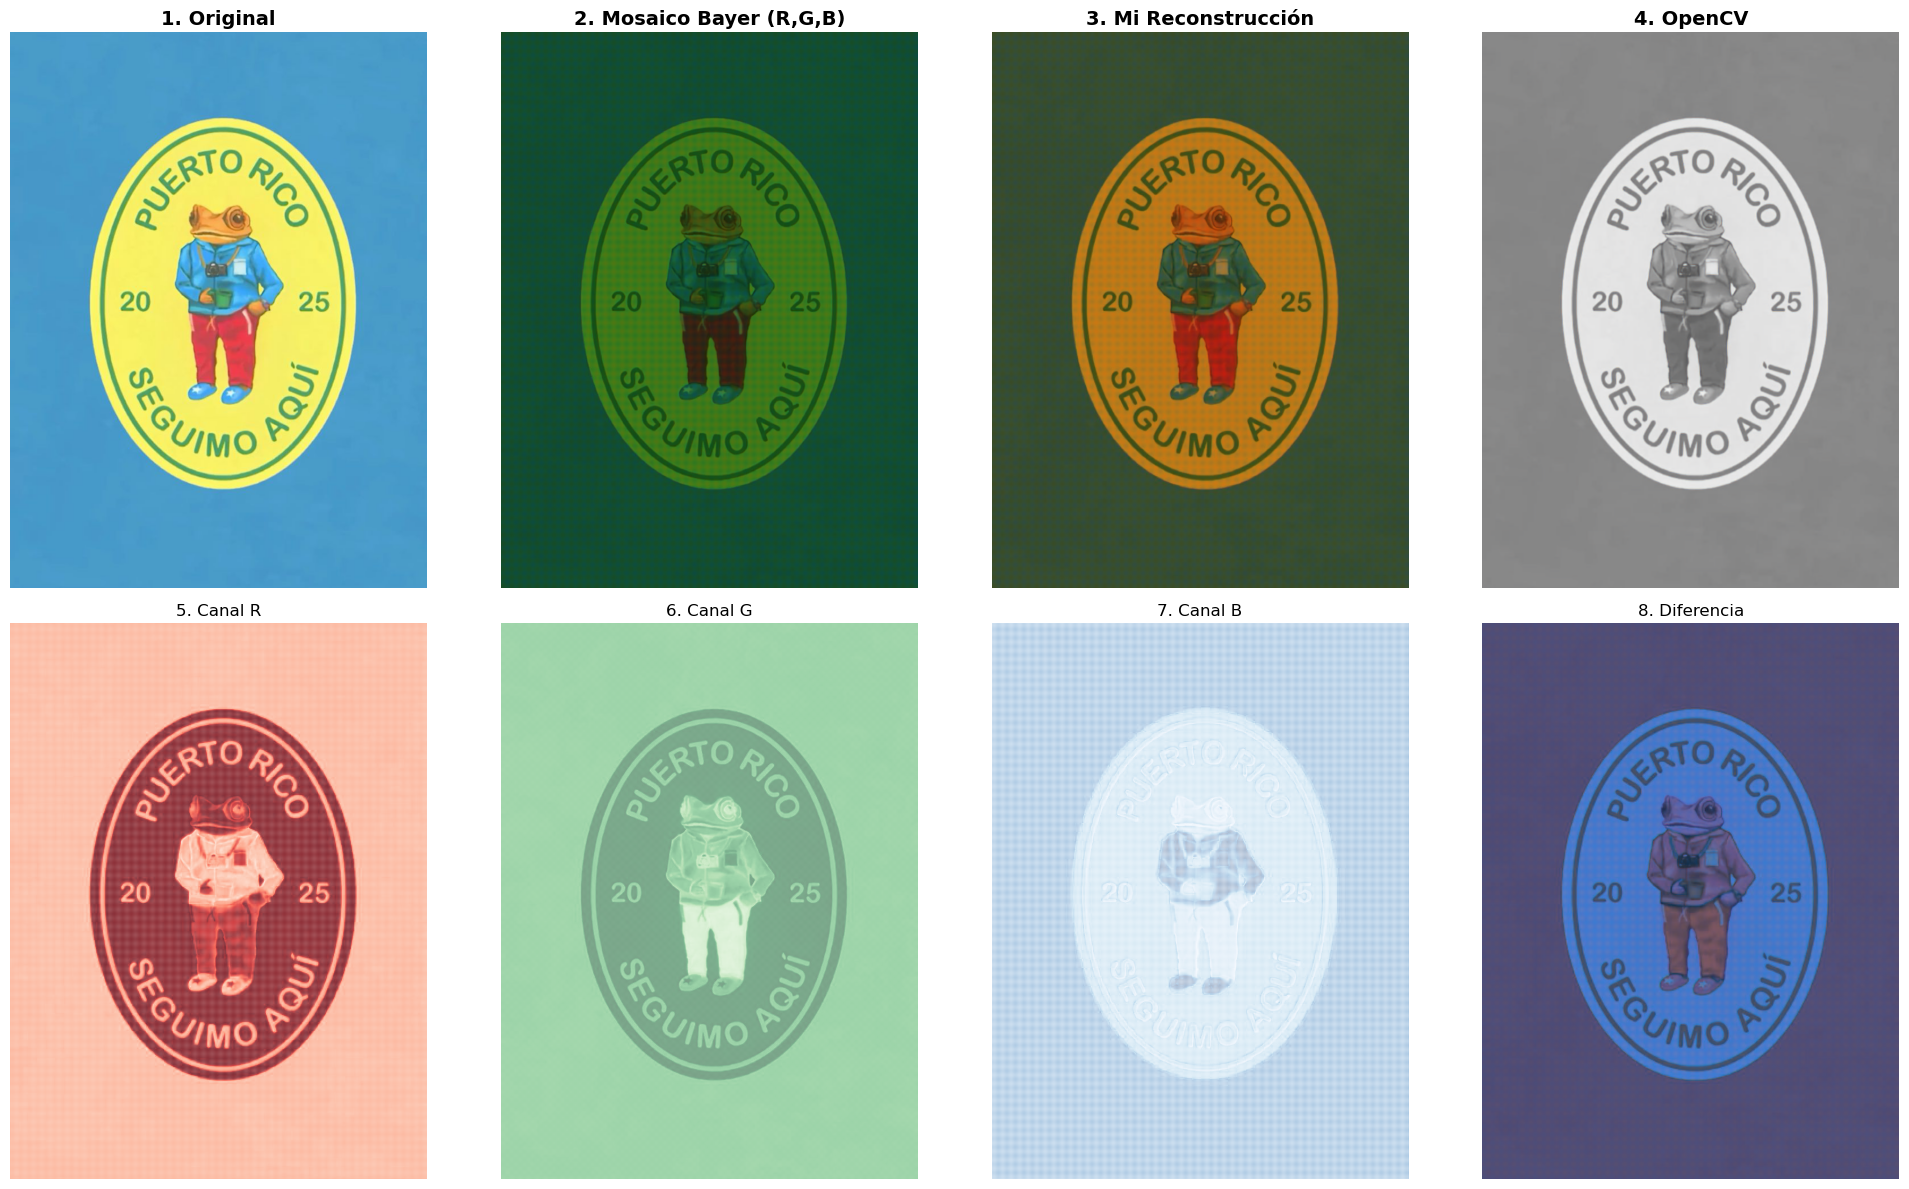

True

In [ ]:
import cv2 
import matplotlib.pyplot as plt
import numpy as np

imagen_color = cv2.imread('concho.jpg')
imagen_rgb = cv2.cvtColor(imagen_color, cv2.COLOR_BGR2RGB)
imagen_gray = cv2.cvtColor(imagen_color, cv2.COLOR_BGR2GRAY)

def crear_bayer_colores(imagen_rgb):
    h, w = imagen_rgb.shape[:2]
    bayer_color = np.zeros((h, w, 3), dtype=np.uint8)
    
    bayer_color[0::2, 0::2, 0] = imagen_rgb[0::2, 0::2, 0]
    bayer_color[0::2, 0::2, 1] = 0
    bayer_color[0::2, 0::2, 2] = 0
    
    bayer_color[0::2, 1::2, 0] = 0
    bayer_color[0::2, 1::2, 1] = imagen_rgb[0::2, 1::2, 1]
    bayer_color[0::2, 1::2, 2] = 0
    
    bayer_color[1::2, 0::2, 0] = 0
    bayer_color[1::2, 0::2, 1] = imagen_rgb[1::2, 0::2, 1]
    bayer_color[1::2, 0::2, 2] = 0
    
    bayer_color[1::2, 1::2, 0] = 0
    bayer_color[1::2, 1::2, 1] = 0
    bayer_color[1::2, 1::2, 2] = imagen_rgb[1::2, 1::2, 2]
    
    return bayer_color

def crear_bayer_grises(imagen_rgb):
    h, w = imagen_rgb.shape[:2]
    bayer = np.zeros((h, w), dtype=np.uint8)
    
    bayer[0::2, 0::2] = imagen_rgb[0::2, 0::2, 0]
    bayer[0::2, 1::2] = imagen_rgb[0::2, 1::2, 1]
    bayer[1::2, 0::2] = imagen_rgb[1::2, 0::2, 1]
    bayer[1::2, 1::2] = imagen_rgb[1::2, 1::2, 2]
    
    return bayer

def reconstruir_simple(bayer):
    h, w = bayer.shape
    resultado = np.zeros((h, w, 3), dtype=np.uint8)
    
    resultado[0::2, 0::2, 0] = bayer[0::2, 0::2]
    resultado[0::2, 1::2, 1] = bayer[0::2, 1::2]
    resultado[1::2, 0::2, 1] = bayer[1::2, 0::2]
    resultado[1::2, 1::2, 2] = bayer[1::2, 1::2]
    
    for i in range(h):
        for j in range(w):
            if i % 2 == 0 and j % 2 == 1:
                resultado[i, j, 1] = bayer[i, j]
                if j > 0:
                    resultado[i, j, 0] = resultado[i, j-1, 0]
                if j < w-1:
                    resultado[i, j, 2] = resultado[i, j+1, 2]
                    
            elif i % 2 == 1 and j % 2 == 0:
                resultado[i, j, 1] = bayer[i, j]
                if i > 0:
                    resultado[i, j, 0] = resultado[i-1, j, 0]
                if i < h-1:
                    resultado[i, j, 2] = resultado[i+1, j, 2]
    
    return resultado


bayer_colores = crear_bayer_colores(imagen_rgb)
bayer_grises = crear_bayer_grises(imagen_rgb)


imagen_reconstruida = reconstruir_simple(bayer_grises)

bayer_opencv = cv2.cvtColor(imagen_gray, cv2.COLOR_BayerRG2BGR)
bayer_opencv_rgb = cv2.cvtColor(bayer_opencv, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20, 12))

plt.subplot(2, 4, 1)
plt.imshow(imagen_rgb)
plt.title('1. Original', fontsize=14, fontweight='bold')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(bayer_colores)
plt.title('2. Mosaico Bayer (R,G,B)', fontsize=14, fontweight='bold')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(imagen_reconstruida)
plt.title('3. Mi Reconstrucción', fontsize=14, fontweight='bold')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(bayer_opencv_rgb)
plt.title('4. OpenCV', fontsize=14, fontweight='bold')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(imagen_reconstruida[:,:,0], cmap='Reds')
plt.title('5. Canal R', fontsize=12)
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(imagen_reconstruida[:,:,1], cmap='Greens')
plt.title('6. Canal G', fontsize=12)
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(imagen_reconstruida[:,:,2], cmap='Blues')
plt.title('7. Canal B', fontsize=12)
plt.axis('off')

diferencia = cv2.absdiff(imagen_reconstruida, bayer_opencv_rgb)
plt.subplot(2, 4, 8)
plt.imshow(diferencia)
plt.title('8. Diferencia', fontsize=12)
plt.axis('off')

plt.tight_layout()
plt.show()

cv2.imwrite('01_original.png', cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('02_bayer_colores.png', cv2.cvtColor(bayer_colores, cv2.COLOR_RGB2BGR))
cv2.imwrite('03_mi_reconstruccion.png', cv2.cvtColor(imagen_reconstruida, cv2.COLOR_RGB2BGR))
cv2.imwrite('04_opencv.png', cv2.cvtColor(bayer_opencv_rgb, cv2.COLOR_RGB2BGR))
